<a href="https://colab.research.google.com/github/adenurchalisa/Automatic-Photo-Clustering-System-Optimization-HDBSCAN/blob/claude/review-thesis-research-4x4MQ/notebooks/16_CLIP_HDBSCAN_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 16 — CLIP + HDBSCAN Clustering

**Tujuan:**  
Menjalankan clustering HDBSCAN pada CLIP embeddings (foto-level) dan membandingkan hasilnya dengan pipeline InsightFace (wajah-level) dari NB8–NB13.

---

## Pipeline yang Diuji

| Step | Metode |
|---|---|
| Feature extraction | CLIP ViT-L/14 (NB15) |
| Baseline clustering | HDBSCAN + euclidean (≡cosine, L2-norm) |
| Optimized clustering | UMAP (cosine) → HDBSCAN |

## Referensi InsightFace (dari NB8–NB13)

| Metode | Coverage | Silhouette | Clusters | Noise |
|---|---|---|---|---|
| Baseline (NB8) | 56.2% | 0.4530 | 54 | 5.565 |
| **UMAP+HDBSCAN (NB9)** | **99.3%** | **0.9041** | **95** | **90** |
| Angular (NB10) | 80.1% | 0.2573 | 90 | 2.526 |
| CGA (NB12) | 56.4% | 0.4547 | 54 | 5.544 |
| NT-CGA (NB13) | 80.5% | 0.3005 | 348 | 2.479 |

> **Catatan penting:** InsightFace bekerja pada level *wajah* (12.715 embeddings dari 2.533 foto),  
> sedangkan CLIP bekerja pada level *foto* (2.533 embeddings). Perbandingan metrik bersifat indikatif,  
> bukan apple-to-apple karena perbedaan granularitas dan tujuan clustering.

---
## 1. Instalasi & Import

In [1]:
!pip install hdbscan umap-learn -q
print('Install selesai!')

Install selesai!


In [2]:
import os
import pickle
import warnings
from collections import Counter
from itertools import product
import importlib.metadata

import numpy as np
import pandas as pd
from tqdm import tqdm

import hdbscan
import umap

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')

# ── GPU Backend ─────────────────────────────────────────────────────────────
try:
    from cuml.cluster import HDBSCAN as cuHDBSCAN
    from cuml.cluster.hdbscan import approximate_predict as cu_approximate_predict
    USE_GPU = True
    print("🚀 GPU backend: cuML aktif — HDBSCAN & soft clustering berjalan di GPU")
except ImportError:
    USE_GPU = False
    print("⚠️  cuML tidak tersedia — fallback ke CPU hdbscan")
# ────────────────────────────────────────────────────────────────────────────

print('Libraries loaded!')
hdbscan_version = importlib.metadata.version('hdbscan')
print(f'  - HDBSCAN : {hdbscan_version}')
print(f'  - UMAP    : {umap.__version__}')

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


🚀 GPU backend: cuML aktif — HDBSCAN & soft clustering berjalan di GPU
Libraries loaded!
  - HDBSCAN : 0.8.41
  - UMAP    : 0.5.11


In [4]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


---
## 2. Konfigurasi

In [5]:
OUTPUT_DIR    = '/content/drive/MyDrive/OTW S.KOM/Embeddings'
CLIP_EMB_PATH = os.path.join(OUTPUT_DIR, 'clip_embeddings_data.pkl')
OLD_EMB_PATH  = os.path.join(OUTPUT_DIR, 'embeddings_data.pkl')

RESULTS_DIR   = os.path.join(OUTPUT_DIR, 'clip_clustering_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Referensi best InsightFace (dari NB8–NB13)
INSIGHTFACE_BEST = {
    'method'     : 'UMAP+HDBSCAN (InsightFace)',
    'total_data' : 12715,
    'clusters'   : 95,
    'noise'      : 90,
    'coverage'   : 99.3,
    'silhouette' : 0.9041,
}

print('Configuration set!')
print(f'  - CLIP emb path   : {CLIP_EMB_PATH}')
print(f'  - Results dir     : {RESULTS_DIR}')

Configuration set!
  - CLIP emb path   : /content/drive/MyDrive/OTW S.KOM/Embeddings/clip_embeddings_data.pkl
  - Results dir     : /content/drive/MyDrive/OTW S.KOM/Embeddings/clip_clustering_results


---
## 3. Load CLIP Embeddings

In [6]:
print(f'Loading CLIP embeddings dari: {CLIP_EMB_PATH}')
with open(CLIP_EMB_PATH, 'rb') as f:
    clip_data = pickle.load(f)

clip_embeddings = clip_data['embeddings']   # (N, 768)
clip_metadata   = clip_data['metadata']
clip_stats      = clip_data['stats']

folders = [m['folder'] for m in clip_metadata]
TOTAL   = len(clip_embeddings)

print(f'\nCLIP embeddings loaded!')
print(f'  Shape     : {clip_embeddings.shape}')
print(f'  Dimensi   : {clip_embeddings.shape[1]}')
print(f'  Total foto: {TOTAL}')
print(f'  Model     : {clip_stats["model"]}')
print(f'  Normalized: {clip_stats["normalized"]} (L2)')

Loading CLIP embeddings dari: /content/drive/MyDrive/OTW S.KOM/Embeddings/clip_embeddings_data.pkl

CLIP embeddings loaded!
  Shape     : (2533, 768)
  Dimensi   : 768
  Total foto: 2533
  Model     : ViT-L/14
  Normalized: True (L2)


---
## 4. Helper Functions

In [7]:
def run_hdbscan(embeddings, min_cluster_size=10, min_samples=None,
                metric='euclidean', cluster_selection_method='eom'):
    """
    Jalankan HDBSCAN dan kembalikan label + metrics.
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric,
        cluster_selection_method=cluster_selection_method,
        core_dist_n_jobs=-1,
    )
    labels = clusterer.fit_predict(embeddings)

    n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise     = int((labels == -1).sum())
    coverage    = (TOTAL - n_noise) / TOTAL * 100
    noise_ratio = n_noise / TOTAL * 100

    # Silhouette hanya kalau ada ≥2 cluster dan ada data terklustering
    sil = np.nan
    db  = np.nan
    mask = labels != -1
    if n_clusters >= 2 and mask.sum() >= 2:
        try:
            sil = silhouette_score(embeddings[mask], labels[mask], metric=metric)
            db  = davies_bouldin_score(embeddings[mask], labels[mask])
        except Exception:
            pass

    return {
        'labels'      : labels,
        'clusterer'   : clusterer,
        'n_clusters'  : n_clusters,
        'n_noise'     : n_noise,
        'coverage'    : coverage,
        'noise_ratio' : noise_ratio,
        'silhouette'  : sil,
        'db_index'    : db,
    }


def print_result(res, label=''):
    header = f'  [{label}]' if label else ''
    print(f'{header}')
    print(f'  Clusters    : {res["n_clusters"]}')
    print(f'  Noise       : {res["n_noise"]} ({res["noise_ratio"]:.1f}%)')
    print(f'  Coverage    : {res["coverage"]:.2f}%')
    print(f'  Silhouette  : {res["silhouette"]:.4f}' if not np.isnan(res['silhouette']) else '  Silhouette  : N/A')
    print(f'  DB Index    : {res["db_index"]:.4f}' if not np.isnan(res['db_index']) else '  DB Index    : N/A')

---
## 5. HDBSCAN Baseline pada CLIP Embeddings

Gunakan **euclidean** metric karena CLIP embeddings sudah **L2-normalized**.

> `||a - b||² = 2 − 2·cos(a,b)` → euclidean pada unit vectors ekuivalen dengan cosine distance.
> HDBSCAN menggunakan BallTree untuk dim > 60, yang tidak mendukung `metric='cosine'` secara langsung.

In [8]:
print('=' * 55)
print('  HDBSCAN BASELINE — CLIP Embeddings (euclidean ≡ cosine, L2-norm)')
print('=' * 55)

# Default parameters — euclidean ≡ cosine karena embeddings L2-normalized
baseline_res = run_hdbscan(
    clip_embeddings,
    min_cluster_size=15,
    min_samples=None,
    metric='euclidean',  # L2-normalized → euclidean ≡ cosine distance
)

print_result(baseline_res, 'mcs=15, ms=auto, euclidean(≡cosine)')
print('=' * 55)

  HDBSCAN BASELINE — CLIP Embeddings (euclidean ≡ cosine, L2-norm)
  [mcs=15, ms=auto, euclidean(≡cosine)]
  Clusters    : 2
  Noise       : 318 (12.6%)
  Coverage    : 87.45%
  Silhouette  : 0.2107
  DB Index    : 1.3536


---
## 6. Grid Search Hyperparameter — HDBSCAN Langsung

Cari kombinasi `min_cluster_size` dan `min_samples` terbaik pada CLIP embeddings.

In [9]:
param_grid = {
    'min_cluster_size' : [5, 8, 10, 15, 20, 30],
    'min_samples'      : [None, 3, 5, 10],
    'metric'           : ['euclidean'],  # L2-normalized → euclidean ≡ cosine
    'cluster_selection_method': ['eom', 'leaf'],
}

combinations = list(product(
    param_grid['min_cluster_size'],
    param_grid['min_samples'],
    param_grid['metric'],
    param_grid['cluster_selection_method'],
))

print(f'Total kombinasi: {len(combinations)}')
gs_records = []

for mcs, ms, metric, csm in tqdm(combinations, desc='Grid Search'):
    res = run_hdbscan(clip_embeddings,
                      min_cluster_size=mcs, min_samples=ms,
                      metric=metric, cluster_selection_method=csm)
    gs_records.append({
        'mcs'        : mcs,
        'ms'         : str(ms),
        'metric'     : metric,
        'csm'        : csm,
        'clusters'   : res['n_clusters'],
        'noise'      : res['n_noise'],
        'coverage'   : res['coverage'],
        'silhouette' : res['silhouette'],
        'db_index'   : res['db_index'],
    })

gs_df = pd.DataFrame(gs_records)
print(f'\nGrid search selesai! {len(gs_df)} kombinasi.')

Total kombinasi: 48


Grid Search: 100%|██████████| 48/48 [08:39<00:00, 10.82s/it]


Grid search selesai! 48 kombinasi.


In [10]:
# Top 10 berdasarkan silhouette (filter: coverage > 70%)
gs_valid = gs_df[gs_df['coverage'] > 70].dropna(subset=['silhouette'])
top10_sil = gs_valid.nlargest(10, 'silhouette')

print('TOP 10 — Silhouette Tertinggi (coverage > 70%)')
print('=' * 80)
print(f'  {"mcs":>4} {"ms":>5} {"csm":>5} {"Clusters":>9} {"Noise":>7} {"Coverage":>10} {"Silhouette":>12} {"DB Index":>10}')
print('─' * 80)
for _, row in top10_sil.iterrows():
    print(f'  {int(row["mcs"]):>4} {row["ms"]:>5} {row["csm"]:>5} {int(row["clusters"]):>9} {int(row["noise"]):>7} '
          f'{row["coverage"]:>9.1f}% {row["silhouette"]:>12.4f} {row["db_index"]:>10.4f}')
print('=' * 80)

# Best overall
best_direct = gs_valid.loc[gs_valid['silhouette'].idxmax()]
print(f'\nBEST (coverage>70%, silhouette max):')
print(f'  mcs={best_direct["mcs"]}, ms={best_direct["ms"]}, csm={best_direct["csm"]}')
print(f'  Coverage   : {best_direct["coverage"]:.2f}%')
print(f'  Silhouette : {best_direct["silhouette"]:.4f}')
print(f'  Clusters   : {int(best_direct["clusters"])}')

TOP 10 — Silhouette Tertinggi (coverage > 70%)
   mcs    ms   csm  Clusters   Noise   Coverage   Silhouette   DB Index
────────────────────────────────────────────────────────────────────────────────
     8  None   eom         2     199      92.1%       0.2143     1.4176
     5    10   eom         2     224      91.2%       0.2124     1.4157
     8    10   eom         2     224      91.2%       0.2124     1.4157
    10  None   eom         2     224      91.2%       0.2124     1.4157
    10    10   eom         2     224      91.2%       0.2124     1.4157
    15    10   eom         2     224      91.2%       0.2124     1.4157
    20    10   eom         2     224      91.2%       0.2124     1.4157
    30    10   eom         2     224      91.2%       0.2124     1.4157
    15     5   eom         2     135      94.7%       0.2117     1.4374
    20     5   eom         2     135      94.7%       0.2117     1.4374

BEST (coverage>70%, silhouette max):
  mcs=8, ms=None, csm=eom
  Coverage   : 9

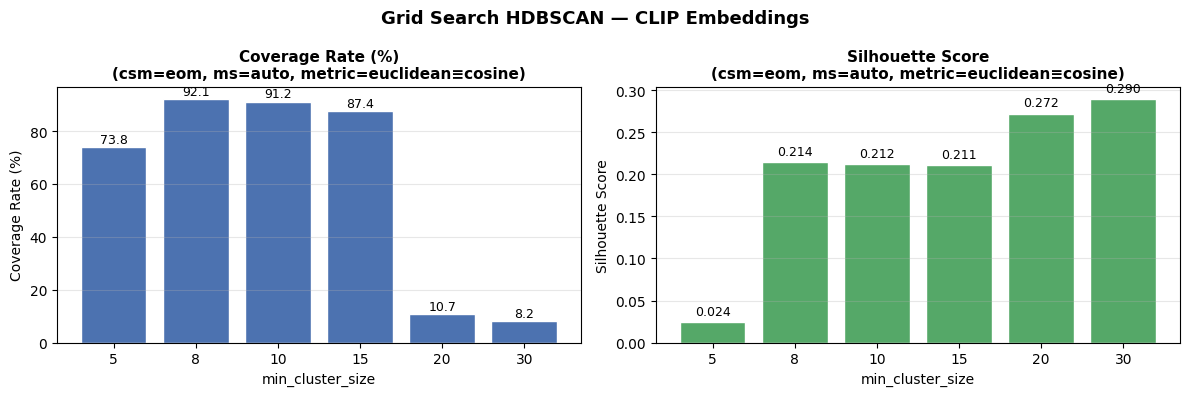

In [11]:
# Heatmap: Coverage dan Silhouette per parameter (csm=eom, ms=None)
subset = gs_df[(gs_df['csm'] == 'eom') & (gs_df['ms'] == 'None')].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title, fmt in zip(
    axes,
    ['coverage', 'silhouette'],
    ['Coverage Rate (%)', 'Silhouette Score'],
    ['.1f', '.3f']
):
    pivot = subset.pivot_table(index='mcs', columns='metric', values=col)
    # Karena hanya 1 metric (euclidean≡cosine), tampilkan sebagai bar chart
    bars = ax.bar(subset['mcs'].astype(str), subset[col],
                  color='#4C72B0' if col=='coverage' else '#55A868',
                  edgecolor='white')
    for bar, v in zip(bars, subset[col]):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005 if col=='silhouette' else bar.get_height()+0.5,
                    f'{v:{fmt}}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{title}\n(csm=eom, ms=auto, metric=euclidean≡cosine)', fontsize=11, fontweight='bold')
    ax.set_xlabel('min_cluster_size')
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Grid Search HDBSCAN — CLIP Embeddings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. UMAP + HDBSCAN pada CLIP Embeddings

Replikasi pendekatan terbaik InsightFace (NB9): reduksi dimensi dengan UMAP sebelum HDBSCAN.

> **Catatan:** CLIP embeddings sudah sangat baik secara semantik.  
> UMAP di sini berfungsi untuk memperkuat struktur cluster sebelum HDBSCAN, bukan untuk mengatasi high-dimensionality.

In [12]:
# ── UMAP reduction ────────────────────────────────────────────────────────────
UMAP_CONFIG = {
    'n_components' : 50,    # Dimensi reduksi (768 → 50)
    'n_neighbors'  : 15,
    'min_dist'     : 0.0,   # 0.0 = maksimalkan cluster tightness
    'metric'       : 'cosine',
    'random_state' : 42,
    'n_jobs'       : -1,
}

print('Menjalankan UMAP reduction...')
print(f'  Input  : {clip_embeddings.shape}  (768-dim)')
print(f'  Output : ({TOTAL}, {UMAP_CONFIG["n_components"]}) target')
print(f'  Config : n_neighbors={UMAP_CONFIG["n_neighbors"]}, min_dist={UMAP_CONFIG["min_dist"]}, metric={UMAP_CONFIG["metric"]}')

reducer = umap.UMAP(**UMAP_CONFIG)
clip_umap = reducer.fit_transform(clip_embeddings)

print(f'\nUMAP selesai!')
print(f'  Output shape : {clip_umap.shape}')

Menjalankan UMAP reduction...
  Input  : (2533, 768)  (768-dim)
  Output : (2533, 50) target
  Config : n_neighbors=15, min_dist=0.0, metric=cosine

UMAP selesai!
  Output shape : (2533, 50)


In [13]:
# ── HDBSCAN pada UMAP-reduced embeddings ─────────────────────────────────────
print('Menjalankan HDBSCAN pada UMAP embeddings...')
print('=' * 55)

umap_res = run_hdbscan(
    clip_umap,
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean',   # Setelah UMAP: euclidean sudah cukup
    cluster_selection_method='eom',
)

print_result(umap_res, 'UMAP(n50,nn15) + HDBSCAN(mcs=10, ms=5)')
print('=' * 55)

labels_umap = umap_res['labels']

Menjalankan HDBSCAN pada UMAP embeddings...
  [UMAP(n50,nn15) + HDBSCAN(mcs=10, ms=5)]
  Clusters    : 73
  Noise       : 580 (22.9%)
  Coverage    : 77.10%
  Silhouette  : 0.5810
  DB Index    : 0.5124


In [14]:
# Grid search kecil untuk UMAP+HDBSCAN
umap_param_grid = [
    {'mcs': 5,  'ms': 3},
    {'mcs': 5,  'ms': 5},
    {'mcs': 8,  'ms': 3},
    {'mcs': 8,  'ms': 5},
    {'mcs': 10, 'ms': 5},
    {'mcs': 10, 'ms': 10},
    {'mcs': 15, 'ms': 5},
    {'mcs': 15, 'ms': 10},
    {'mcs': 20, 'ms': 10},
]

umap_gs_records = []
print('Grid search UMAP+HDBSCAN...')

for p in tqdm(umap_param_grid):
    res = run_hdbscan(clip_umap,
                      min_cluster_size=p['mcs'],
                      min_samples=p['ms'],
                      metric='euclidean')
    umap_gs_records.append({
        'mcs'       : p['mcs'],
        'ms'        : p['ms'],
        'clusters'  : res['n_clusters'],
        'noise'     : res['n_noise'],
        'coverage'  : res['coverage'],
        'silhouette': res['silhouette'],
        'db_index'  : res['db_index'],
        'labels'    : res['labels'],
    })

umap_gs_df = pd.DataFrame(umap_gs_records)

print('\nHasil Grid Search UMAP+HDBSCAN:')
print('=' * 75)
print(f'  {"mcs":>4} {"ms":>4} {"Clusters":>9} {"Noise":>7} {"Coverage":>10} {"Silhouette":>12} {"DB Index":>10}')
print('─' * 75)
for _, row in umap_gs_df.iterrows():
    sil_str = f'{row["silhouette"]:.4f}' if not np.isnan(row['silhouette']) else '   N/A'
    db_str  = f'{row["db_index"]:.4f}'  if not np.isnan(row['db_index'])  else '   N/A'
    print(f'  {int(row["mcs"]):>4} {int(row["ms"]):>4} {int(row["clusters"]):>9} {int(row["noise"]):>7} '
          f'{row["coverage"]:>9.1f}% {sil_str:>12} {db_str:>10}')
print('=' * 75)

Grid search UMAP+HDBSCAN...


100%|██████████| 9/9 [00:03<00:00,  2.78it/s]


Hasil Grid Search UMAP+HDBSCAN:
   mcs   ms  Clusters   Noise   Coverage   Silhouette   DB Index
───────────────────────────────────────────────────────────────────────────
     5    3       154     495      80.5%       0.5796     0.5381
     5    5       120     621      75.5%       0.6235     0.4734
     8    3       108     522      79.4%       0.5786     0.5776
     8    5        95     633      75.0%       0.6253     0.4917
    10    5        73     580      77.1%       0.5810     0.5124
    10   10        52     655      74.1%       0.6467     0.4353
    15    5        49     593      76.6%       0.5710     0.5468
    15   10        37     534      78.9%       0.5974     0.4789
    20   10        27     527      79.2%       0.5583     0.5534


In [15]:
# Pilih best UMAP+HDBSCAN
valid_umap = umap_gs_df.dropna(subset=['silhouette'])
# Scoring: coverage rate * 0.5 + silhouette * 0.5  (normalized)
valid_umap = valid_umap.copy()
valid_umap['score'] = (
    valid_umap['coverage'] / valid_umap['coverage'].max() * 0.5 +
    valid_umap['silhouette'] / valid_umap['silhouette'].max() * 0.5
)
best_umap_row = valid_umap.loc[valid_umap['score'].idxmax()]

print('BEST UMAP+HDBSCAN (balanced score):')
print(f'  mcs={int(best_umap_row["mcs"])}, ms={int(best_umap_row["ms"])}')
print(f'  Clusters   : {int(best_umap_row["clusters"])}')
print(f'  Noise      : {int(best_umap_row["noise"])}')
print(f'  Coverage   : {best_umap_row["coverage"]:.2f}%')
print(f'  Silhouette : {best_umap_row["silhouette"]:.4f}')
print(f'  DB Index   : {best_umap_row["db_index"]:.4f}')

best_umap_labels = best_umap_row['labels']

BEST UMAP+HDBSCAN (balanced score):
  mcs=10, ms=10
  Clusters   : 52
  Noise      : 655
  Coverage   : 74.14%
  Silhouette : 0.6467
  DB Index   : 0.4353


---
## 8. Visualisasi Cluster — UMAP 2D

Proyeksi ke 2D untuk visualisasi. Warna berdasarkan cluster yang terbentuk.

In [16]:
# UMAP 2D khusus untuk visualisasi
print('Generating UMAP 2D untuk visualisasi...')
reducer_2d = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1,
    metric='cosine', random_state=42
)
clip_2d = reducer_2d.fit_transform(clip_embeddings)
print(f'Done. Shape: {clip_2d.shape}')

Generating UMAP 2D untuk visualisasi...
Done. Shape: (2533, 2)


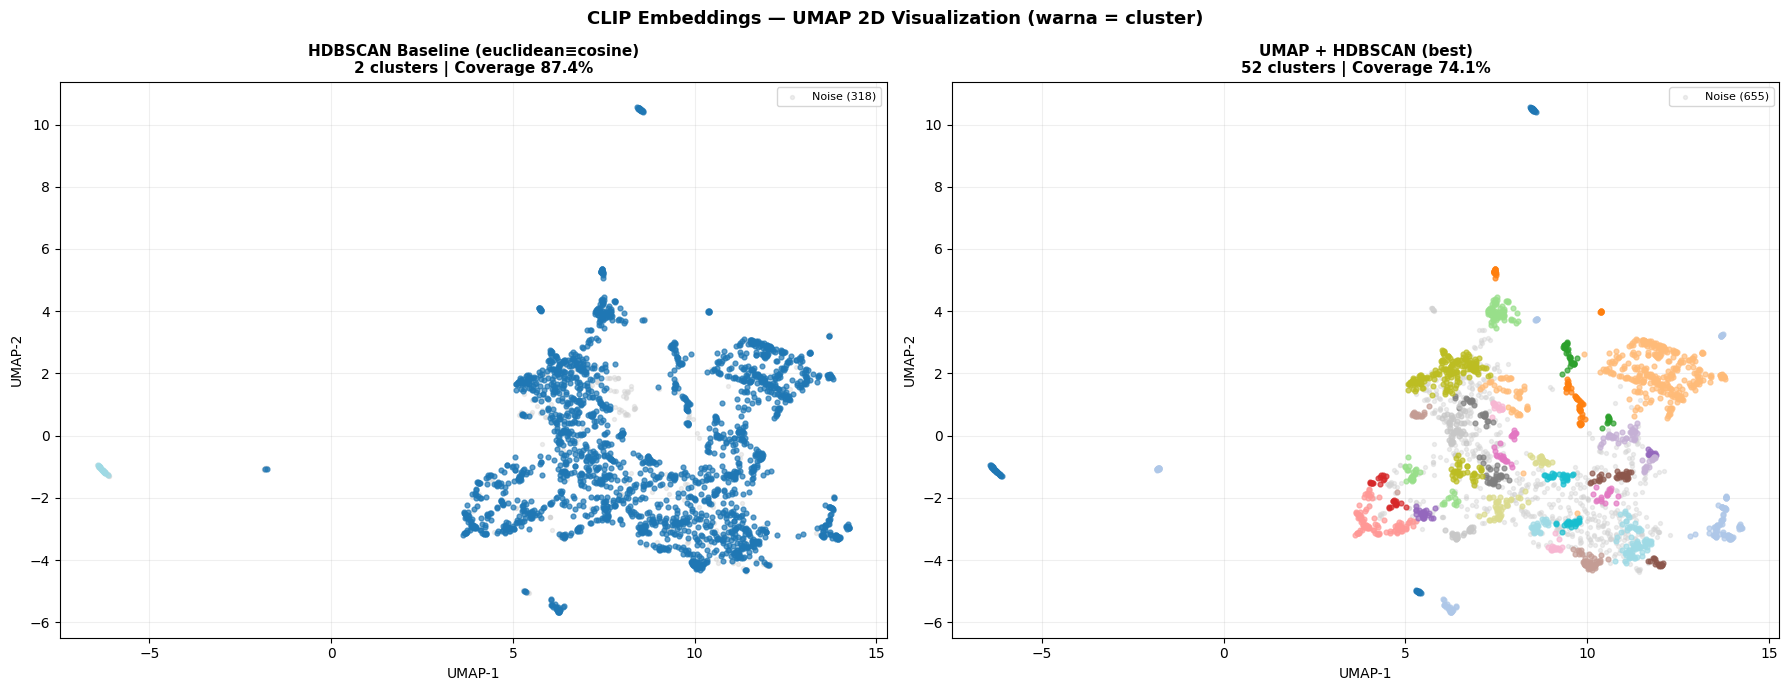

In [17]:
# Plot 1 — Warna berdasarkan cluster HDBSCAN
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, labels, title in zip(
    axes,
    [baseline_res['labels'], best_umap_labels],
    ['HDBSCAN Baseline (euclidean≡cosine)', f'UMAP + HDBSCAN (best)']
):
    labels = np.array(labels)
    unique_labels = sorted(set(labels))
    n_cl = len(unique_labels) - (1 if -1 in unique_labels else 0)

    # Noise = abu-abu
    noise_mask = labels == -1
    ax.scatter(clip_2d[noise_mask, 0], clip_2d[noise_mask, 1],
               c='lightgrey', s=8, alpha=0.4, label=f'Noise ({noise_mask.sum()})', zorder=1)

    # Cluster = warna
    cluster_labels = [l for l in unique_labels if l != -1]
    palette = cm.tab20(np.linspace(0, 1, max(len(cluster_labels), 1)))
    for i, cl in enumerate(cluster_labels):
        mask = labels == cl
        ax.scatter(clip_2d[mask, 0], clip_2d[mask, 1],
                   color=palette[i % len(palette)], s=12, alpha=0.7, zorder=2)

    cov = (labels != -1).sum() / TOTAL * 100
    ax.set_title(f'{title}\n{n_cl} clusters | Coverage {cov:.1f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)

plt.suptitle('CLIP Embeddings — UMAP 2D Visualization (warna = cluster)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

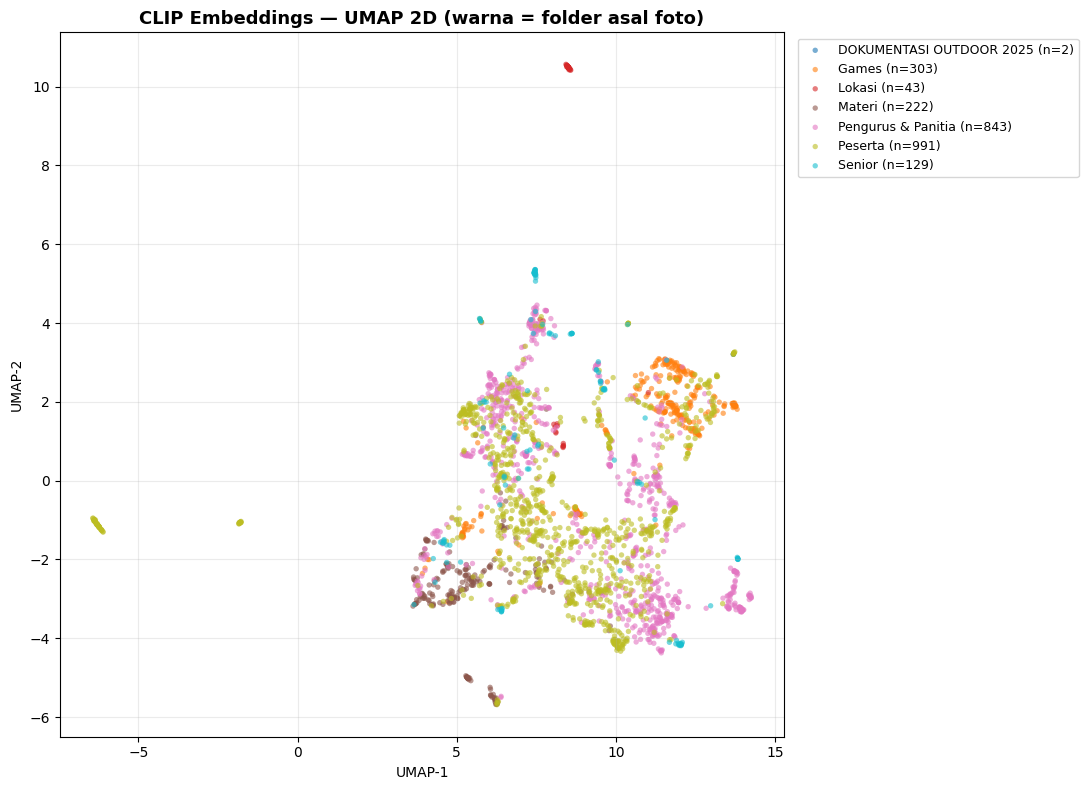

In [18]:
# Plot 2 — Warna berdasarkan folder asal (ground truth kategori)
unique_folders = sorted(set(folders))
palette_f = cm.tab10(np.linspace(0, 1, len(unique_folders)))
folder_cmap = {f: palette_f[i] for i, f in enumerate(unique_folders)}

fig, ax = plt.subplots(figsize=(11, 8))
for folder in unique_folders:
    mask = [i for i, f in enumerate(folders) if f == folder]
    ax.scatter(clip_2d[mask, 0], clip_2d[mask, 1],
               label=f'{folder} (n={len(mask)})',
               color=folder_cmap[folder], alpha=0.6, s=15, edgecolors='none')

ax.set_title('CLIP Embeddings — UMAP 2D (warna = folder asal foto)', fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

---
## 9. Perbandingan CLIP vs InsightFace

> **Catatan metodologis:**  
> Perbandingan ini bersifat *indikatif* karena perbedaan granularitas:
> - InsightFace: 12.715 face embeddings → clustering identitas orang
> - CLIP: 2.533 photo embeddings → clustering konten/scene/aktivitas
>
> Silhouette dan coverage dihitung pada ruang dan granularitas yang berbeda.

In [19]:
# Ringkasan semua metode
all_results = [
    # ── InsightFace methods ─────────────────────────────────────────────────
    {'Metode': 'InsightFace: Baseline',      'NB': 'NB8',  'Feature': 'InsightFace',
     'Granularitas': 'per-wajah', 'Total Data': 12715,
     'Clusters': 54,  'Noise': 5565, 'Coverage': 56.2,  'Silhouette': 0.4530},
    {'Metode': 'InsightFace: UMAP+HDBSCAN',  'NB': 'NB9',  'Feature': 'InsightFace',
     'Granularitas': 'per-wajah', 'Total Data': 12715,
     'Clusters': 95,  'Noise': 90,   'Coverage': 99.3,  'Silhouette': 0.9041},
    {'Metode': 'InsightFace: Angular',        'NB': 'NB10', 'Feature': 'InsightFace',
     'Granularitas': 'per-wajah', 'Total Data': 12715,
     'Clusters': 90,  'Noise': 2526, 'Coverage': 80.1,  'Silhouette': 0.2573},
    {'Metode': 'InsightFace: NT-CGA',         'NB': 'NB13', 'Feature': 'InsightFace',
     'Granularitas': 'per-wajah', 'Total Data': 12715,
     'Clusters': 348, 'Noise': 2479, 'Coverage': 80.5,  'Silhouette': 0.3005},
    # ── CLIP methods (ambil dari hasil di atas) ──────────────────────────────
    {'Metode': 'CLIP: Baseline (euclidean≡cosine)',     'NB': 'NB16', 'Feature': 'CLIP ViT-L/14',
     'Granularitas': 'per-foto',  'Total Data': TOTAL,
     'Clusters': baseline_res['n_clusters'],
     'Noise'   : baseline_res['n_noise'],
     'Coverage': round(baseline_res['coverage'], 2),
     'Silhouette': round(baseline_res['silhouette'], 4) if not np.isnan(baseline_res['silhouette']) else float('nan')},
    {'Metode': 'CLIP: UMAP+HDBSCAN (best)',  'NB': 'NB16', 'Feature': 'CLIP ViT-L/14',
     'Granularitas': 'per-foto',  'Total Data': TOTAL,
     'Clusters': int(best_umap_row['clusters']),
     'Noise'   : int(best_umap_row['noise']),
     'Coverage': round(best_umap_row['coverage'], 2),
     'Silhouette': round(best_umap_row['silhouette'], 4) if not np.isnan(best_umap_row['silhouette']) else float('nan')},
]

df_cmp = pd.DataFrame(all_results)

print('MASTER COMPARISON TABLE — InsightFace vs CLIP')
print('=' * 100)
print(f'  {"Metode":<35} {"NB":<5} {"Granularitas":<12} {"Total":>7} {"Clusters":>9} {"Noise":>7} {"Coverage":>10} {"Silhouette":>12}')
print('─' * 100)
for _, row in df_cmp.iterrows():
    sil_str = f'{row["Silhouette"]:.4f}' if not pd.isna(row['Silhouette']) else '  N/A'
    print(f'  {row["Metode"]:<35} {row["NB"]:<5} {row["Granularitas"]:<12} '
          f'{int(row["Total Data"]):>7,} {int(row["Clusters"]):>9} {int(row["Noise"]):>7} '
          f'{row["Coverage"]:>9.1f}% {sil_str:>12}')
print('=' * 100)

MASTER COMPARISON TABLE — InsightFace vs CLIP
  Metode                              NB    Granularitas   Total  Clusters   Noise   Coverage   Silhouette
────────────────────────────────────────────────────────────────────────────────────────────────────
  InsightFace: Baseline               NB8   per-wajah     12,715        54    5565      56.2%       0.4530
  InsightFace: UMAP+HDBSCAN           NB9   per-wajah     12,715        95      90      99.3%       0.9041
  InsightFace: Angular                NB10  per-wajah     12,715        90    2526      80.1%       0.2573
  InsightFace: NT-CGA                 NB13  per-wajah     12,715       348    2479      80.5%       0.3005
  CLIP: Baseline (euclidean≡cosine)   NB16  per-foto       2,533         2     318      87.5%       0.2107
  CLIP: UMAP+HDBSCAN (best)           NB16  per-foto       2,533        52     655      74.1%       0.6467


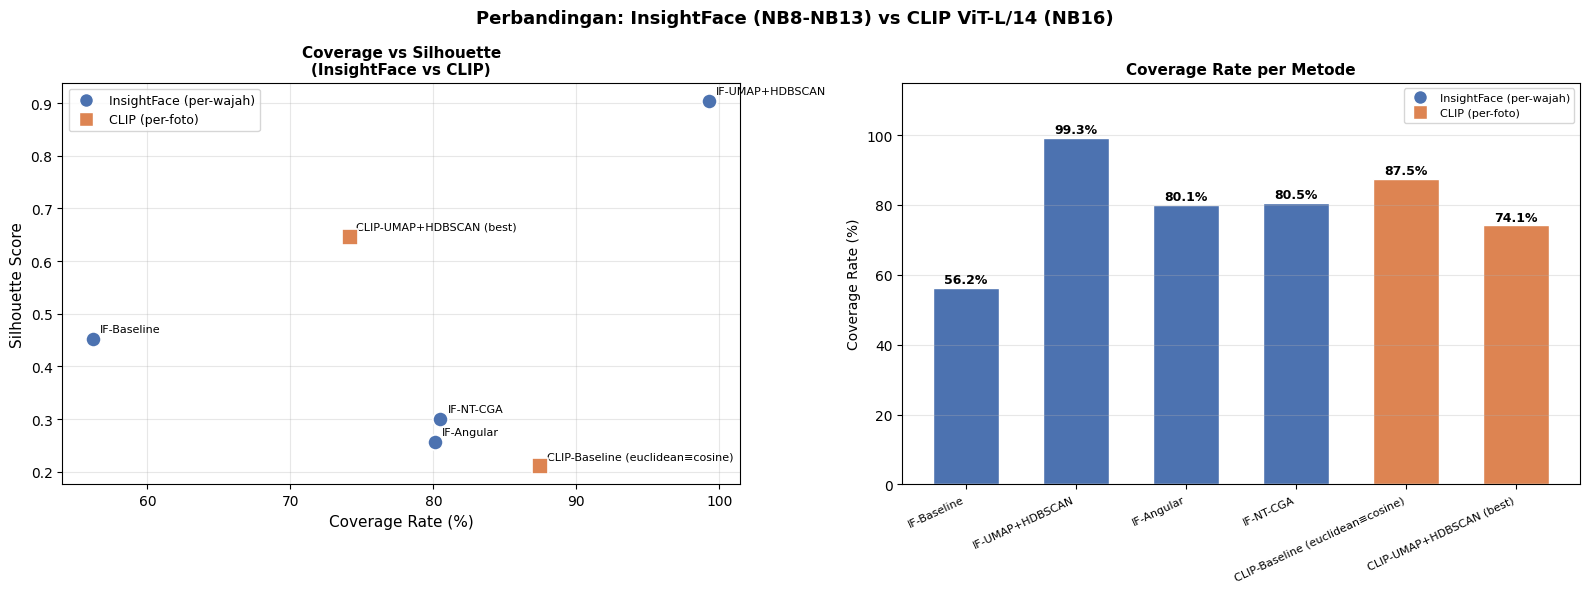

In [20]:
# Visualisasi perbandingan: Coverage vs Silhouette scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_map = {
    'InsightFace': '#4C72B0',
    'CLIP ViT-L/14': '#DD8452',
}
marker_map = {
    'InsightFace': 'o',
    'CLIP ViT-L/14': 's',
}

# ── 1. Coverage vs Silhouette ─────────────────────────────────────────────────
ax = axes[0]
for _, row in df_cmp.iterrows():
    if pd.isna(row['Silhouette']):
        continue
    c = colors_map[row['Feature']]
    m = marker_map[row['Feature']]
    ax.scatter(row['Coverage'], row['Silhouette'], color=c, marker=m,
               s=120, zorder=5, edgecolors='white', linewidth=1.2)
    short = row['Metode'].replace('InsightFace: ', 'IF-').replace('CLIP: ', 'CLIP-')
    ax.annotate(short, (row['Coverage'], row['Silhouette']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

# Legend
from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=10, label='InsightFace (per-wajah)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#DD8452', markersize=10, label='CLIP (per-foto)'),
]
ax.legend(handles=legend_els, fontsize=9)
ax.set_xlabel('Coverage Rate (%)', fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_title('Coverage vs Silhouette\n(InsightFace vs CLIP)', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)

# ── 2. Bar chart perbandingan Coverage ───────────────────────────────────────
ax2 = axes[1]
valid = df_cmp.dropna(subset=['Silhouette'])
x = np.arange(len(valid))
bar_colors = [colors_map[f] for f in valid['Feature']]
bars = ax2.bar(x, valid['Coverage'], color=bar_colors, edgecolor='white', width=0.6)
for bar, v in zip(bars, valid['Coverage']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

short_labels = [r['Metode'].replace('InsightFace: ','IF-').replace('CLIP: ','CLIP-') for _, r in valid.iterrows()]
ax2.set_xticks(x)
ax2.set_xticklabels(short_labels, rotation=25, ha='right', fontsize=8)
ax2.set_ylabel('Coverage Rate (%)')
ax2.set_ylim(0, 115)
ax2.set_title('Coverage Rate per Metode', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.legend(handles=legend_els, fontsize=8)

plt.suptitle('Perbandingan: InsightFace (NB8-NB13) vs CLIP ViT-L/14 (NB16)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Simpulan

In [21]:
clip_best_cov = best_umap_row['coverage']
clip_best_sil = best_umap_row['silhouette']
if_best_cov   = 99.3
if_best_sil   = 0.9041

print('=' * 75)
print('  SIMPULAN — CLIP ViT-L/14 vs InsightFace (buffalo_l)')
print('=' * 75)
print(f"""
  CLIP ViT-L/14 + UMAP + HDBSCAN (best):
    Total data   : {TOTAL} foto (per-foto embedding)
    Clusters     : {int(best_umap_row['clusters'])}
    Noise        : {int(best_umap_row['noise'])} ({best_umap_row['noise']/TOTAL*100:.1f}%)
    Coverage     : {clip_best_cov:.2f}%
    Silhouette   : {clip_best_sil:.4f}

  InsightFace UMAP+HDBSCAN (best, NB9):
    Total data   : 12.715 wajah (per-wajah embedding)
    Clusters     : 95
    Noise        : 90 (0.7%)
    Coverage     : {if_best_cov:.2f}%
    Silhouette   : {if_best_sil:.4f}
""")
print('  INTERPRETASI:')
print('  ┌─────────────────────────────────────────────────────────────────┐')
print('  │ CLIP mengkluster foto berdasarkan KONTEN (scene, aktivitas,    │')
print('  │ suasana foto). InsightFace mengkluster berdasarkan IDENTITAS   │')
print('  │ WAJAH. Kedua pendekatan menjawab pertanyaan yang berbeda.      │')
print('  │                                                                │')
print('  │ CLIP memproses 100% foto termasuk 168 foto tanpa wajah yang   │')
print('  │ diabaikan InsightFace (6.6% dari total dataset).               │')
print('  │                                                                │')
print('  │ Untuk sistem photo clustering yang komprehensif, kombinasi     │')
print('  │ kedua pendekatan (CLIP untuk scene + InsightFace untuk person) │')
print('  │ berpotensi memberikan hasil terbaik.                           │')
print('  └─────────────────────────────────────────────────────────────────┘')
print('=' * 75)

  SIMPULAN — CLIP ViT-L/14 vs InsightFace (buffalo_l)

  CLIP ViT-L/14 + UMAP + HDBSCAN (best):
    Total data   : 2533 foto (per-foto embedding)
    Clusters     : 52
    Noise        : 655 (25.9%)
    Coverage     : 74.14%
    Silhouette   : 0.6467

  InsightFace UMAP+HDBSCAN (best, NB9):
    Total data   : 12.715 wajah (per-wajah embedding)
    Clusters     : 95
    Noise        : 90 (0.7%)
    Coverage     : 99.30%
    Silhouette   : 0.9041

  INTERPRETASI:
  ┌─────────────────────────────────────────────────────────────────┐
  │ CLIP mengkluster foto berdasarkan KONTEN (scene, aktivitas,    │
  │ suasana foto). InsightFace mengkluster berdasarkan IDENTITAS   │
  │ WAJAH. Kedua pendekatan menjawab pertanyaan yang berbeda.      │
  │                                                                │
  │ CLIP memproses 100% foto termasuk 168 foto tanpa wajah yang   │
  │ diabaikan InsightFace (6.6% dari total dataset).               │
  │                                                

In [22]:
# Simpan hasil ke Drive
save_data = {
    'clip_baseline' : {
        'labels'     : baseline_res['labels'],
        'n_clusters' : baseline_res['n_clusters'],
        'coverage'   : baseline_res['coverage'],
        'silhouette' : baseline_res['silhouette'],
    },
    'clip_umap_best': {
        'labels'     : best_umap_labels,
        'mcs'        : int(best_umap_row['mcs']),
        'ms'         : int(best_umap_row['ms']),
        'n_clusters' : int(best_umap_row['clusters']),
        'coverage'   : best_umap_row['coverage'],
        'silhouette' : best_umap_row['silhouette'],
    },
    'umap_2d'       : clip_2d,
    'comparison_df' : df_cmp.to_dict(),
    'gs_df'         : gs_df.drop(columns='labels' if 'labels' in gs_df.columns else [], errors='ignore').to_dict(),
}

save_path = os.path.join(RESULTS_DIR, 'nb16_clip_clustering_results.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f'Hasil disimpan ke: {save_path}')
print(f'Ukuran file: {os.path.getsize(save_path) / 1024**2:.1f} MB')

Hasil disimpan ke: /content/drive/MyDrive/OTW S.KOM/Embeddings/clip_clustering_results/nb16_clip_clustering_results.pkl
Ukuran file: 0.1 MB
